# LiDAR processing step 2: MMDetection3D, PointPillars, conversion to BEV
- NOTE: Our BEV grid will be (x= [0, 250]m; y: [-90, 90]m)
- we use resolution 0.5m along both axes 
--> grid resolution is therefore 500 x 360. 
- z∈[-5,3] meters (MMDetection3D PointPillars nuScenes config uses this range for z-axis, so good place to start: https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html) 
- [-5, 3] is low enough to include road dips / slopes and high enough to include pedestrians, cars, poles, and other near-road objects. We are essentially restricting the z-axis to a physically relevant region to save compute.

In [1]:
# ============================================================
# Load BEV LiDAR points saved as .bin
# ============================================================

import numpy as np
from pathlib import Path

# Path to saved file
bin_path = Path("/home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin")

# ------------------------------------------------------------
# Read raw binary float32 values
# ------------------------------------------------------------

raw = np.fromfile(bin_path, dtype=np.float32)
print(f"raw.shape: {raw.shape}")

# ------------------------------------------------------------
# Reshape into (N,4) → [x,y,z,intensity]
# ------------------------------------------------------------

fov_points_ego_xyzi = raw.reshape(-1, 4)
print(f"fov_points_ego_xyzi.shape: {fov_points_ego_xyzi.shape}")

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Loaded file:", bin_path)
print("Dtype:", fov_points_ego_xyzi.dtype)
print("First point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")


raw.shape: (295532,)
fov_points_ego_xyzi.shape: (73883, 4)
Loaded file: /home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin
Dtype: float32
First point: [47.478405 56.58517   8.407365 62.      ]


In [3]:
# Imports + MMDetection3D LiDAR BEV pipeline setup
# Pipeline:
# points -> voxelization -> HardSimpleVFE -> SparseEncoder -> BEV feature map

import numpy as np
import torch
import matplotlib.pyplot as plt

from mmengine.registry import init_default_scope
from mmcv.ops import Voxelization

from mmdet3d.models.voxel_encoders import HardSimpleVFE
from mmdet3d.models.middle_encoders import SparseEncoder

init_default_scope("mmdet3d")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# BEV bounds
X_MIN, X_MAX = 0.0, 250.0
Y_MIN, Y_MAX = -90.0, 90.0
Z_MIN, Z_MAX = -5.0, 3.0

# voxel size (similar to BEVFusion configs)
VOXEL_X = 0.5
VOXEL_Y = 0.5
VOXEL_Z = 0.2

point_cloud_range = [X_MIN, Y_MIN, Z_MIN, X_MAX, Y_MAX, Z_MAX]
voxel_size = [VOXEL_X, VOXEL_Y, VOXEL_Z]

NX = int((X_MAX - X_MIN) / VOXEL_X)
NY = int((Y_MAX - Y_MIN) / VOXEL_Y)
NZ = int((Z_MAX - Z_MIN) / VOXEL_Z)

sparse_shape = [NZ + 1, NY, NX]

print("point_cloud_range:", point_cloud_range)
print("voxel_size:", voxel_size)
print("sparse_shape:", sparse_shape)


device: cuda
point_cloud_range: [0.0, -90.0, -5.0, 250.0, 90.0, 3.0]
voxel_size: [0.5, 0.5, 0.2]
sparse_shape: [41, 360, 500]


In [4]:
# Load ego-frame XYZI points and filter to voxelization region

pts_xyzi = fov_points_ego_xyzi.astype(np.float32)
print("Raw fov_points_ego_xyzi shape:", pts_xyzi.shape)

mask = (
    (pts_xyzi[:, 0] >= X_MIN) & (pts_xyzi[:, 0] < X_MAX) &
    (pts_xyzi[:, 1] >= Y_MIN) & (pts_xyzi[:, 1] < Y_MAX) &
    (pts_xyzi[:, 2] >= Z_MIN) & (pts_xyzi[:, 2] < Z_MAX)
)

pts_xyzi = pts_xyzi[mask]
print("Points after filtering:", pts_xyzi.shape)

# HardSimpleVFE expects 5 features → add dummy channel
dummy = np.zeros((pts_xyzi.shape[0], 1), dtype=np.float32)
pts_xyzit = np.concatenate([pts_xyzi, dummy], axis=1)

points_tensor = torch.from_numpy(pts_xyzit).to(device)


Raw fov_points_ego_xyzi shape: (73883, 4)
Points after filtering: (51421, 4)


In [5]:
# Default LiDAR BEV encoder:
# points -> voxels -> HardSimpleVFE -> SparseEncoder -> BEV tensor

voxel_layer = Voxelization(
    voxel_size=voxel_size,
    point_cloud_range=point_cloud_range,
    max_num_points=10,
    max_voxels=40000,
)

voxel_encoder = HardSimpleVFE(
    num_features=5
).to(device).eval()

middle_encoder = SparseEncoder(
    in_channels=5,
    sparse_shape=sparse_shape,
    order=("conv", "norm", "act"),
    encoder_channels=((16,16,32),(32,32,64),(64,64,128),(128,128)),
    encoder_paddings=((0,0,1),(0,0,1),(0,0,(1,1,0)),(0,0)),
    block_type="basicblock"
).to(device).eval()

with torch.no_grad():

    voxels, coors, num_points = voxel_layer(points_tensor)

    print("voxels:", voxels.shape)
    print("coors:", coors.shape)

    # add batch index
    batch_idx = torch.zeros((coors.shape[0],1), dtype=coors.dtype, device=coors.device)
    coors_batch = torch.cat([batch_idx, coors], dim=1)

    voxel_features = voxel_encoder(voxels, num_points, coors_batch)

    bev_feature_map = middle_encoder(
        voxel_features,
        coors_batch,
        batch_size=1
    )

    print("voxel_features:", voxel_features.shape)
    print("bev_feature_map:", bev_feature_map.shape)


voxels: torch.Size([13167, 10, 5])
coors: torch.Size([13167, 3])
voxel_features: torch.Size([13167, 5])
bev_feature_map: torch.Size([1, 256, 45, 62])


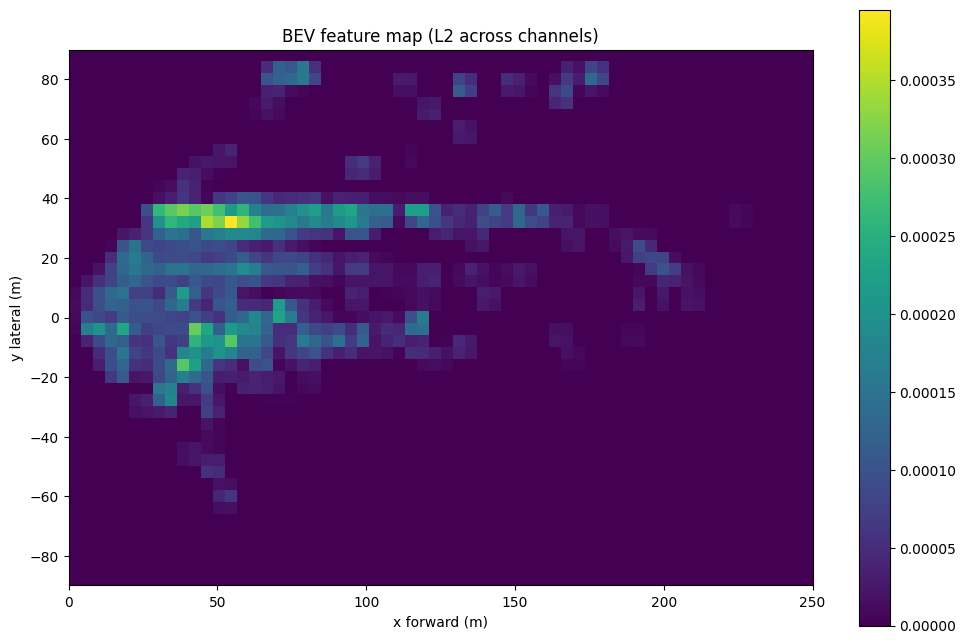

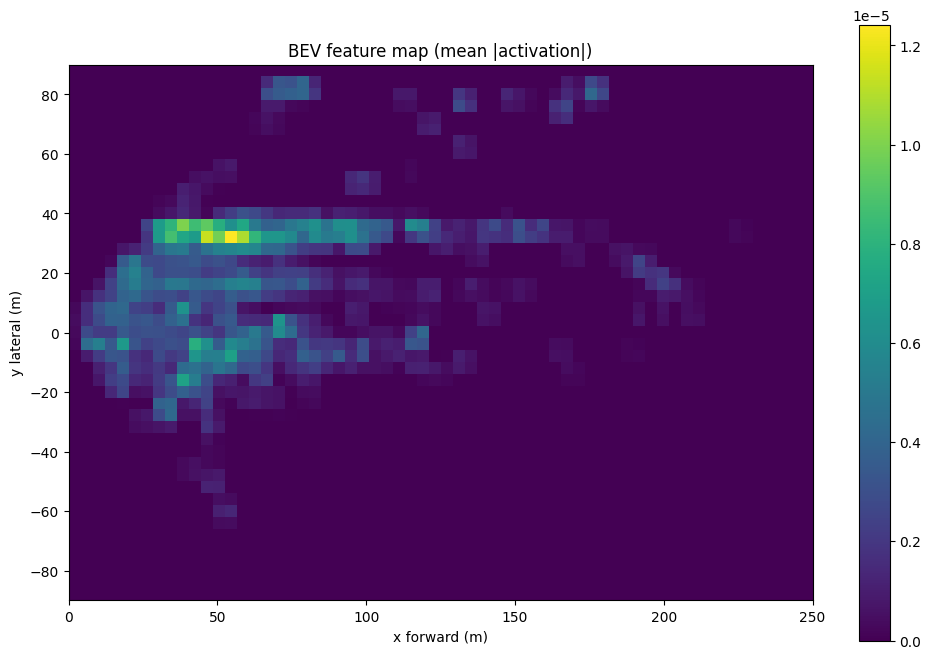

In [6]:
# Visualize BEV feature activations

bev = bev_feature_map.detach().cpu()[0]

bev_l2 = torch.norm(bev, dim=0).numpy()
bev_mean = bev.abs().mean(dim=0).numpy()

extent = [X_MIN, X_MAX, Y_MIN, Y_MAX]

plt.figure(figsize=(12,8))
plt.imshow(bev_l2, origin="lower", extent=extent, aspect="equal")
plt.title("BEV feature map (L2 across channels)")
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar()
plt.show()

plt.figure(figsize=(12,8))
plt.imshow(bev_mean, origin="lower", extent=extent, aspect="equal")
plt.title("BEV feature map (mean |activation|)")
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar()
plt.show()


In [7]:
print(bev_feature_map.shape)


torch.Size([1, 256, 45, 62])


In [13]:
# Run SECOND + SECONDFPN using an even-sized BEV tensor so the FPN branches align

from mmdet3d.models.backbones import SECOND
from mmdet3d.models.necks import SECONDFPN
import torch.nn.functional as F

# Pad BEV feature map so H and W are even before SECOND / SECONDFPN.
# This avoids 45 vs 46 mismatches after stride-2 downsampling / upsampling.
_, _, H, W = bev_feature_map.shape
pad_h = H % 2
pad_w = W % 2

# F.pad format for 4D tensors is (left, right, top, bottom)
bev_feature_map_padded = F.pad(bev_feature_map, (0, pad_w, 0, pad_h))

print("Original bev_feature_map shape:", tuple(bev_feature_map.shape))
print("Padded   bev_feature_map shape:", tuple(bev_feature_map_padded.shape))

bev_backbone = SECOND(
    in_channels=256,
    out_channels=[128, 256],
    layer_nums=[5, 5],
    layer_strides=[1, 2],
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01),
    conv_cfg=dict(type="Conv2d", bias=False),
).to(device).eval()

bev_neck = SECONDFPN(
    in_channels=[128, 256],
    out_channels=[256, 256],
    upsample_strides=[1, 2],
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01),
    upsample_cfg=dict(type="deconv", bias=False),
    use_conv_for_no_stride=True,   # matches official BEVFusion config
).to(device).eval()

with torch.no_grad():
    backbone_feats = bev_backbone(bev_feature_map_padded)
    neck_feats = bev_neck(backbone_feats)

    print("Number of backbone feature maps:", len(backbone_feats))
    for i, feat in enumerate(backbone_feats):
        print(f"backbone_feats[{i}] shape:", tuple(feat.shape))

    print("Number of neck feature maps:", len(neck_feats))
    for i, feat in enumerate(neck_feats):
        print(f"neck_feats[{i}] shape:", tuple(feat.shape))


Original bev_feature_map shape: (1, 256, 45, 62)
Padded   bev_feature_map shape: (1, 256, 46, 62)
Number of backbone feature maps: 2
backbone_feats[0] shape: (1, 128, 46, 62)
backbone_feats[1] shape: (1, 256, 23, 31)
Number of neck feature maps: 1
neck_feats[0] shape: (1, 512, 46, 62)


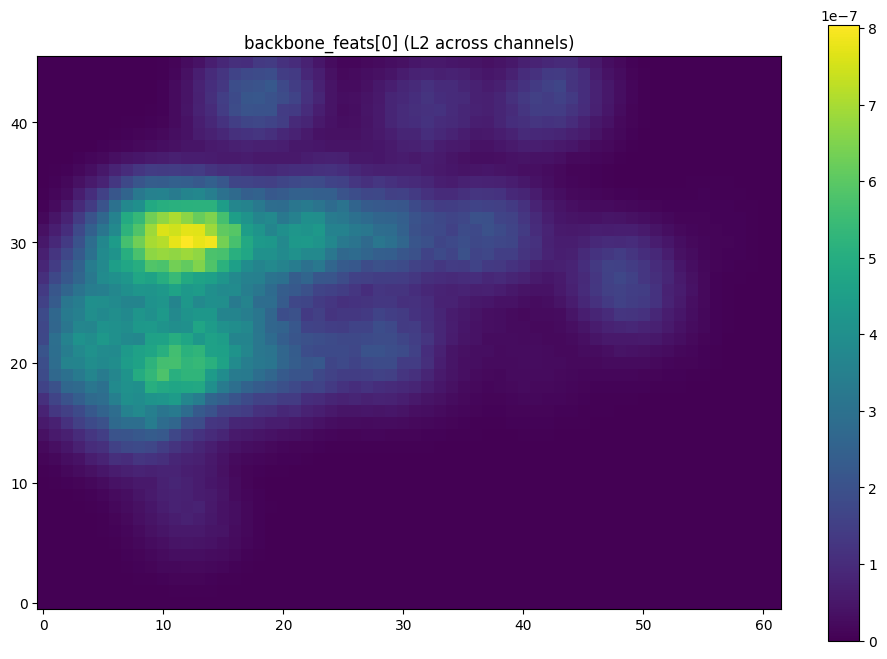

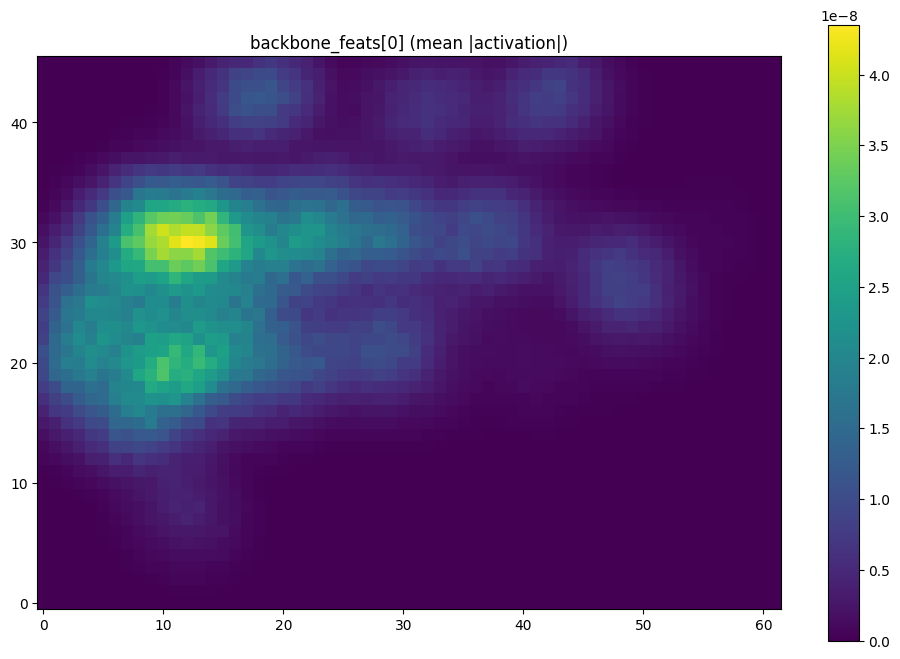

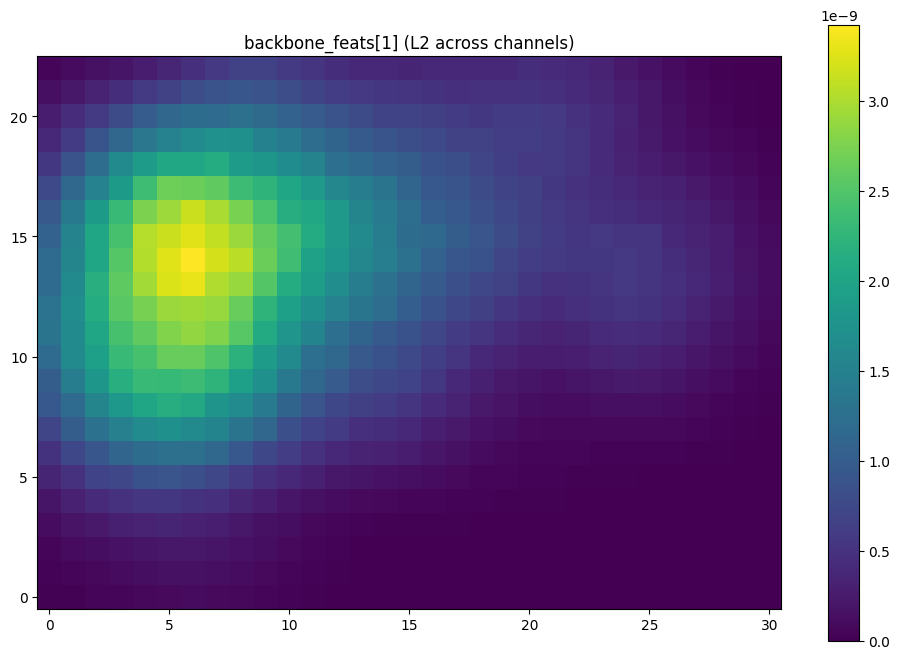

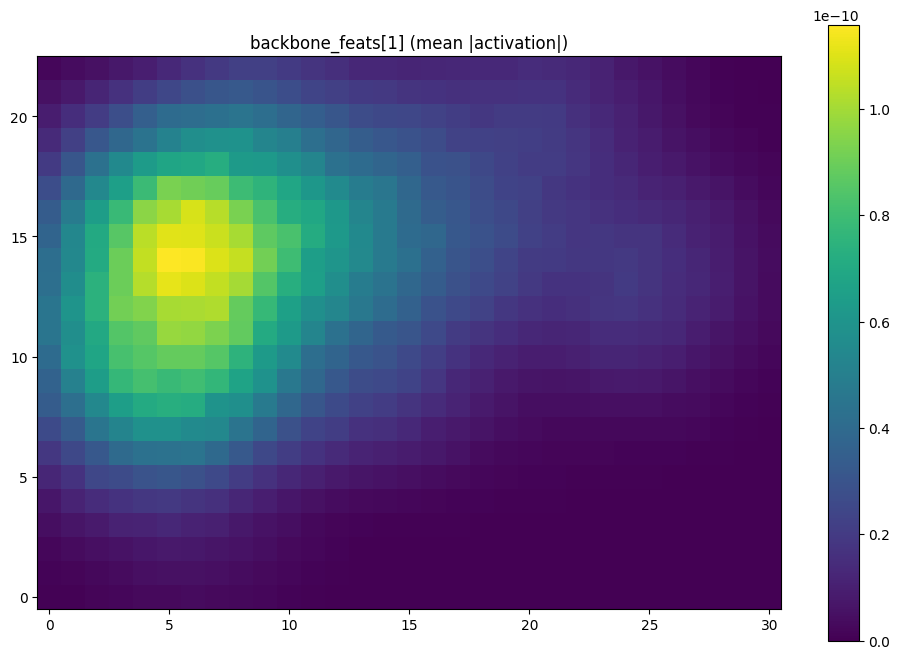

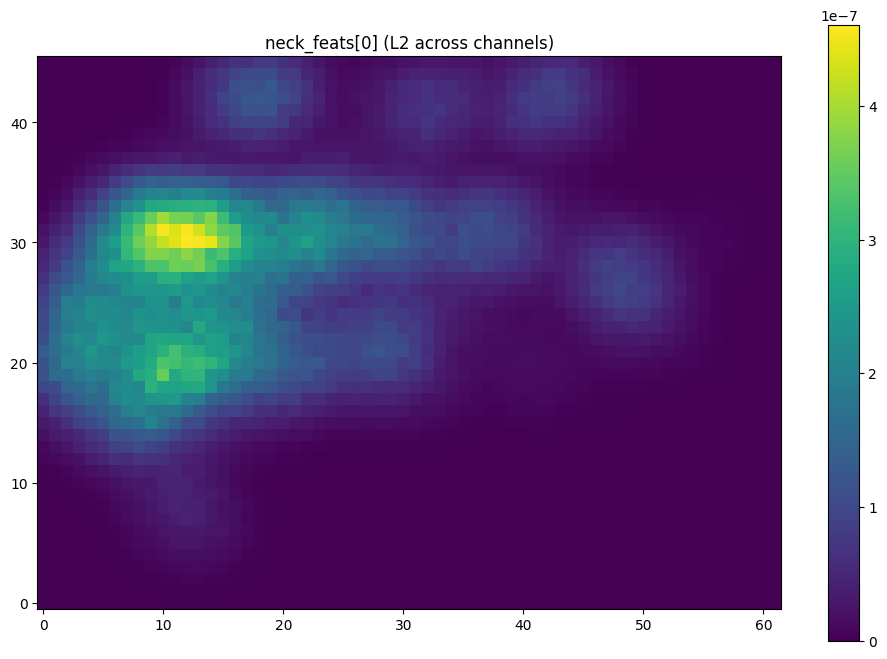

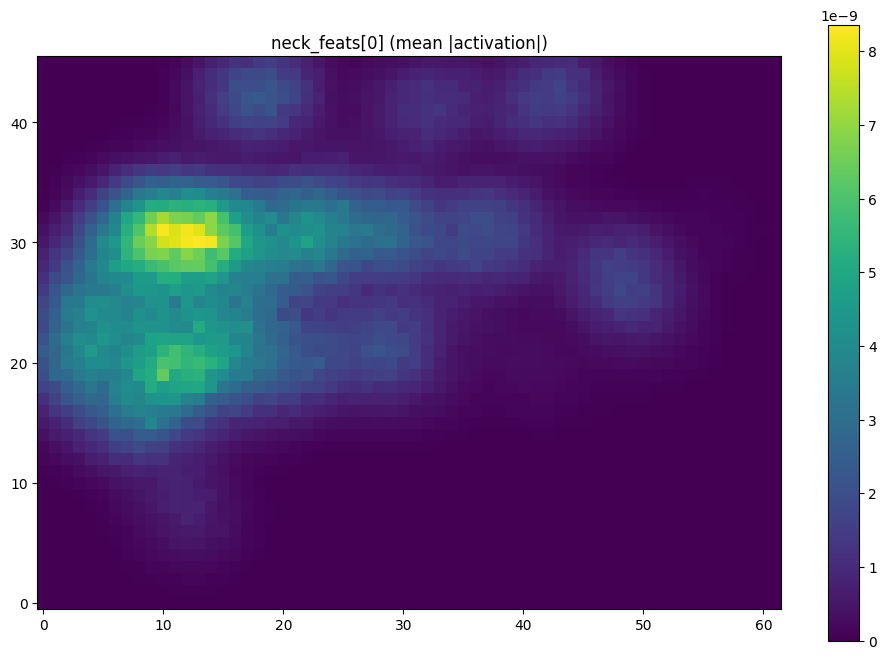

In [14]:
# Visualize backbone and neck feature maps

import matplotlib.pyplot as plt

def summarize_bev(x):
    x = x.detach().cpu()[0]   # [C, H, W]
    l2 = torch.norm(x, dim=0).numpy()
    mean_abs = x.abs().mean(dim=0).numpy()
    return l2, mean_abs

for i, feat in enumerate(backbone_feats):
    feat_l2, feat_mean = summarize_bev(feat)

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_l2, origin="lower", aspect="equal")
    plt.title(f"backbone_feats[{i}] (L2 across channels)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_mean, origin="lower", aspect="equal")
    plt.title(f"backbone_feats[{i}] (mean |activation|)")
    plt.colorbar()
    plt.show()

for i, feat in enumerate(neck_feats):
    feat_l2, feat_mean = summarize_bev(feat)

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_l2, origin="lower", aspect="equal")
    plt.title(f"neck_feats[{i}] (L2 across channels)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_mean, origin="lower", aspect="equal")
    plt.title(f"neck_feats[{i}] (mean |activation|)")
    plt.colorbar()
    plt.show()
